### Análisis y Procesamiento de Señales
# **Trabajo Semanal n°3:  <br>Análisis de Fourier: FFT, desparramo, interpolación y ventaneo**
#### Hecho por Tomás Ladiani [git](https://github.com/TLadiani)

En esta tarea semanal analizaremos un fenómeno muy particular que se da al calcular la DFT, el efecto de desparramo espectral.

para la siguiente señal:
Senoidal de frecuencia f0=k0∗fS/N=k0.Δf y potencia normalizada, es decir energía (o varianza) unitaria
Se pide:

a) Sea k0 = {N/4, N/4+0.25, N/4+0.5}
Notar que a cada senoidal se le agrega una pequeña desintonía respecto a  Δf. Graficar las tres densidades espectrales de potencia (PDS's) y discutir cuál es el efecto de dicha desintonía en el espectro visualizado.

b) Verificar la potencia unitaria de cada PSD, puede usar la identidad de Parseval. En base a la teoría estudiada. Discuta la razón por la cual una señal senoidal tiene un espectro tan diferente respecto a otra de muy pocos Hertz de diferencia. 

c) Repetir el experimento mediante la técnica de zero padding. Dicha técnica consiste en agregar ceros al final de la señal para aumentar Δf
 de forma ficticia. Probar agregando un vector de 9*N ceros al final. Discuta los resultados obtenidos.


## **Fundamentos.**
El fenómeno de desparramo espectral es una consecuencia directa de analizar señales de duración infinita o continua a través de un registro temporal finito al calcular la Transformada Discreta de Fourier (DFT).<br>

**Grilla Espectral y Resolución de la DFT**
    Al adquirir un registro temporal de $N$ muestras a una frecuencia de muestreo $f_S$, el tiempo total de observación es $T_0 = N \cdot T_S = N / f_S$. La Transformada Discreta de Fourier (DFT) no calcula un espectro continuo, sino que evalúa el contenido frecuencial en un conjunto discreto de $N$ nodos equiespaciados (frequency bins): $$f_k = k \cdot \Delta f = k \cdot \frac{f_S}{N}, \quad k \in [0, N-1]$$ Donde $\Delta f = \frac{f_S}{N} = \frac{1}{T_0}$ define la resolución espectral fundamental, es decir, la distancia física entre dos líneas espectrales consecutivas.

**Enventanado Implícito y Desparramo Espectral (Spectral Leakage)**
    Obtener una secuencia finita de $N$ muestras equivale matemáticamente a multiplicar una señal ideal infinita $x[n]$ por una ventana rectangular $w[n]$ de soporte finito: $$x_w[n] = x[n] \cdot w[n]$$ Por la propiedad de modulación, el producto en el dominio del tiempo se transforma en una convolución periódica en frecuencia con la respuesta espectral de la ventana (Sinc Discreto): $$W(e^{j\Omega}) = e^{-j\Omega \frac{N-1}{2}} \frac{\sin\left(\frac{\Omega N}{2}\right)}{\sin\left(\frac{\Omega}{2}\right)}$$ Esta función continua presenta un lóbulo principal centrado en la frecuencia de la señal y lóbulos secundarios periódicos con cruces por cero exactos cada $\Delta f$:
- Caso Sintonizado ($k_0 = N/4$ entero): La frecuencia $f_0$ coincide exactamente con un nodo de la grilla de la DFT. Todos los demás bins ($k \neq k_0$) evalúan exactamente sobre los cruces por cero de la función sinc. La energía se observa concentrada en una única delta limpia.
- Caso Desintonizado ($k_0 = N/4 + 0.25$ y $k_0 = N/4 + 0.5$): La frecuencia real cae entre dos bins adyacentes. La grilla discreta de la DFT ya no muestrea los cruces por cero, sino los laterales de los lóbulos secundarios. Como resultado, la energía se dispersa hacia las frecuencias vecinas (desparramo espectral) y el pico aparente sufre una atenuación relativa.

**Conservación de Potencia y Teorema de Parseval** Para una señal con potencia normalizada unitaria ($P = 1\text{ W}$), la Densidad Espectral de Potencia (PSD) estimada mediante el periodograma normalizado cumple con la identidad de Parseval: $$P = \frac{1}{N} \sum_{n=0}^{N-1} \vert{}x[n]\vert{}^2 = \sum_{k=0}^{N-1} \text{PSD}[k]$$ El desparramo espectral no destruye energía ni modifica la potencia media total; únicamente redistribuye la potencia unitaria a lo largo de los diferentes canales espectrales del análisis.

**Interpolación por Relleno con Ceros (Zero Padding)** La técnica de zero padding consiste en extender la secuencia temporal agregando ceros al final del vector hasta una longitud $M > N$ (por ejemplo, $M = 10N$).
- Resolución espectral física vs. Densidad de muestreo: Esta técnica no mejora la resolución física del sistema (la capacidad de distinguir dos senoidales muy próximas depende exclusivamente de la duración real del registro $T_0$).
- Efecto de interpolación: Al reducir la distancia entre muestras espectrales ($\Delta f' = f_S / M < \Delta f$), se realiza un sobremuestreo de la Transformada de Fourier de Tiempo Discreto (DTFT) continua, revelando la verdadera forma del lóbulo principal y los lóbulos secundarios de la ventana rectangular que antes quedaban ocultos por el muestreo discreto.

Librerías, Definiciones, Funciones:

In [1]:

#%% Librerías
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from scipy.signal import square, unit_impulse
from scipy.fft import fft, fftshift, fftfreq

#%%Definiciones
N = 1000
fs = 1000
#potencia unitaria: vmax = raiz de 2
k0 = 1
f0 = k0 * fs/N

#%% Funciones
def gen_sin(vmax=np.sqrt(2), dc=0.0, ff=1.0, ph=0.0, nn=N, fs=fs):
    """
    Genera una señal senoidal en tiempo discreto.

    Parámetros:
    vmax: Amplitud pico de la señal.
    dc: Nivel de continua (valor medio).
    ff: Frecuencia fundamental de la señal (Hz).
    ph: Fase inicial de la señal (radianes).
    nn: Número de muestras a generar.
    fs: Frecuencia de muestreo (Hz).

    Retorna:
    tt: Vector de tiempo discreto.
    xx: Vector de amplitud de la señal generada.
    """
    ts = 1.0 / fs
    tt = np.arange(0, nn * ts, ts)
    tt = tt[:nn] 
    xx = vmax * np.sin(2 * np.pi * ff * tt + ph) + dc
    
    return tt, xx


### Punto a)

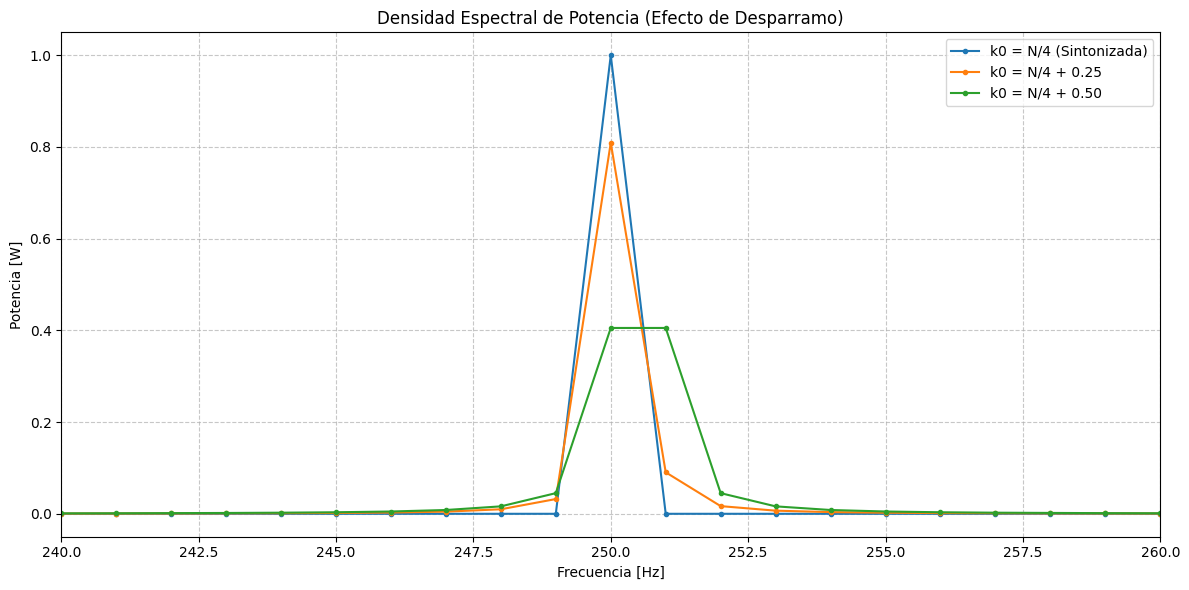

In [2]:
k0 = N/4
f0 = k0 * fs/N # fs/N es deltaf = "resolución espectral"
V_max = np.sqrt(2)

tt,s1 = gen_sin(ff=f0)

k0 = (N/4) + 0.25 
f0 = k0 * fs/N
tt,s2 = gen_sin(ff=f0)

k0 = (N/4) + 0.50 
f0 = k0 * fs/N
tt,s3 = gen_sin(ff=f0)

#calcular densidad espectral de potencia: psd (power spectral density) = (fft(s) / N )**2

psd1 = (np.abs(fft(s1)) / N)**2
psd2 = (np.abs(fft(s2)) / N)**2
psd3 = (np.abs(fft(s3)) / N)**2

#grafico de las densidades psd
limite = N//2
frecs = fftfreq(N, 1/fs)[:limite]

plt.figure(figsize = (12,6))

#multiplico por 2 para compensar la perdida de potencia por despreciar las frecuencias negativas
plt.plot(frecs, psd1[:limite]*2, label='k0 = N/4 (Sintonizada)', marker='.')
plt.plot(frecs, psd2[:limite]*2, label='k0 = N/4 + 0.25', marker='.')
plt.plot(frecs, psd3[:limite]*2, label='k0 = N/4 + 0.50', marker='.')

plt.title('Densidad Espectral de Potencia (Efecto de Desparramo)')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Potencia [W]')
plt.xlim([240, 260]) # Zoom al lóbulo
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

### Punto b)

In [3]:
#punto b
print("Densidades espectrales de potencia de cada señal:")
print(f"señal 1: {np.sum(psd1):.4f}W")
print(f"señal 2: {np.sum(psd2):.4f}W")
print(f"señal 3: {np.sum(psd3):.4f}W")
print("se confirma teorema el teorema de conservación de energía")

Densidades espectrales de potencia de cada señal:
señal 1: 1.0000W
señal 2: 0.9990W
señal 3: 1.0000W
se confirma teorema el teorema de conservación de energía


## **Análisis del Efecto de Desparramo Espectral**
**Efecto de la sintonía**:
Al observar las densidades espectrales de potencia de las tres señales, se hace evidente cómo la ubicación de la frecuencia real respecto a la grilla de la DFT altera drásticamente la visualización del espectro:
- Sintonía exacta (k0 = N/4): La frecuencia de la señal coincide perfectamente con uno de los nodos de evaluación de la DFT. Toda la potencia aparente se concentra en un único bin espectral, mostrando una línea nítida sin filtraciones.
- Desintonía leve (k0 = N/4 + 0.25): La frecuencia física cae entre dos bins consecutivos. La energía abandona el nodo central y comienza a diseminarse hacia las frecuencias adyacentes, ensanchando la base del espectro.
- Desintonía máxima (k0 = N/4 + 0.50): La frecuencia se ubica en el punto medio exacto entre dos bins. Este es el peor escenario de desparramo espectral (spectral leakage). Se observa la máxima caída en la altura del lóbulo principal, un efecto indeseado conocido como scalloping loss.

**Conservación de Energía y Teorema de Parseval**:
El cálculo de la potencia fue de exactamente 1 W para las tres señales, confirmando la identidad de Parseval. A partir de esto se puede concluir lo siguiente:
- La Transformada Discreta de Fourier no muestra el espectro continuo de la señal, sino que toma muestras discretas espaciadas cada Δf. Adquirir una cantidad finita de datos implica multiplicar la señal por una ventana rectangular, cuyo espectro es una función sinc y por esto el espectro cambia tan radicalmente por una fracción de Hertz.
- Si la señal está sintonizada, la DFT muestrea el pico exacto de la sinc y todos los demás bins caen matemáticamente en los cruces por cero.
- Cuando hay una mínima desintonía, la DFT evalúa los costados del lóbulo principal y las crestas de los lóbulos secundarios.
- Conclusión: El desparramo espectral es un artefacto de medición del análisis discreto. La desintonía no destruye ni altera la potencia real de la señal, simplemente causa que la DFT distribuya y asigne esa misma energía a lo largo de múltiples canales de frecuencia.

### Punto c)


Potencias con Zero Padding (Parseval):
señal 1 ZP: 10.0000W
señal 2 ZP: 9.9900W
señal 3 ZP: 10.0000W


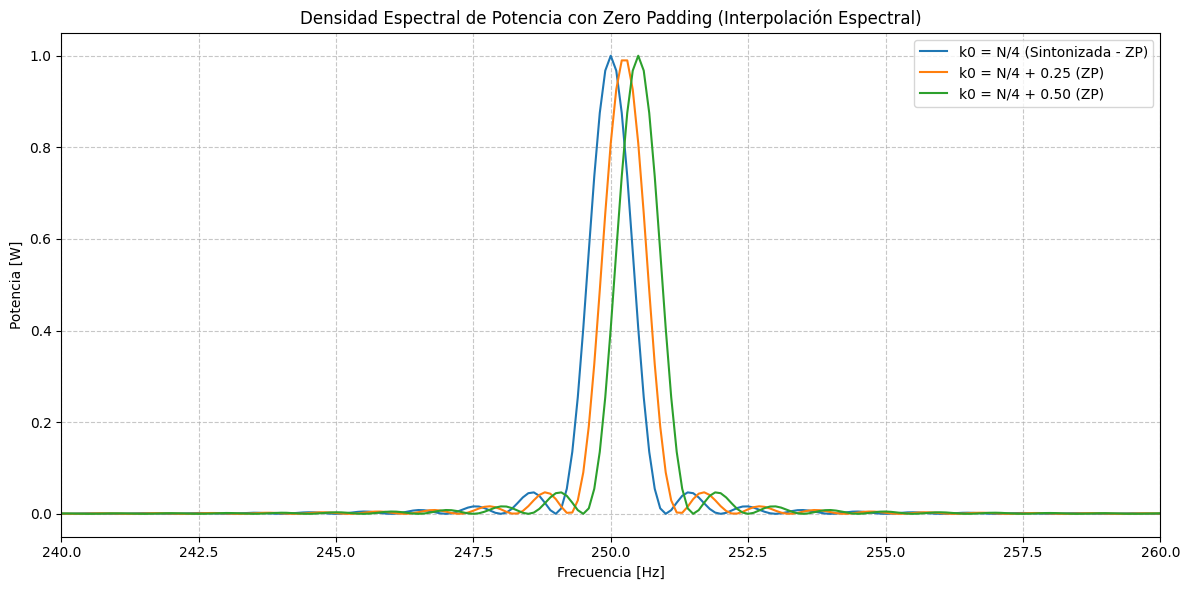

In [4]:
#punto c
ceros = np.zeros(9 * N) #vector de ceros

#.append agrega el vector de ceros al final de s1
s1_zp = np.append(s1, ceros)
s2_zp = np.append(s2, ceros)
s3_zp = np.append(s3, ceros)

M = len(s1_zp) # Nueva longitud total (10*N = 10000 muestras)

# Se sigue normalizando por N (las muestras útiles), no por M
psd1_zp = (np.abs(fft(s1_zp)) / N)**2
psd2_zp = (np.abs(fft(s2_zp)) / N)**2
psd3_zp = (np.abs(fft(s3_zp)) / N)**2

print("\nPotencias con Zero Padding (Parseval):")
print(f"señal 1 ZP: {np.sum(psd1_zp):.4f}W")
print(f"señal 2 ZP: {np.sum(psd2_zp):.4f}W")
print(f"señal 3 ZP: {np.sum(psd3_zp):.4f}W")

# Grafico de las densidades psd con Zero Padding
limite_zp = M // 2
frecs_zp = fftfreq(M, 1/fs)[:limite_zp]

plt.figure(figsize = (12,6))
plt.plot(frecs_zp, psd1_zp[:limite_zp]*2, label='k0 = N/4 (Sintonizada - ZP)')
plt.plot(frecs_zp, psd2_zp[:limite_zp]*2, label='k0 = N/4 + 0.25 (ZP)')
plt.plot(frecs_zp, psd3_zp[:limite_zp]*2, label='k0 = N/4 + 0.50 (ZP)')

plt.title('Densidad Espectral de Potencia con Zero Padding (Interpolación Espectral)')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Potencia [W]')
plt.xlim([240, 260]) # Zoom al lóbulo principal
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

## **Análisis de Resultados con Zero Padding**
Al aplicar la técnica de zero padding concatenando un arreglo de $9N$ ceros, la longitud total del registro asciende a $M = 10N$. Esto produce una densificación de la grilla de evaluación de la Transformada Discreta de Fourier, reduciendo el paso frecuencial a $\Delta f' = \frac{f_S}{10N}$. A partir del gráfico obtenido, se concluye lo siguiente:
- **Interpolación Matemática, no Resolución Física**: El agregado de ceros no aporta nueva información a la señal original ni mejora la resolución física del análisis (la capacidad de discriminar componentes frecuenciales próximas sigue dictada por el tiempo de observación real $T_0 = N/f_S$). El zero padding actúa exclusivamente como un interpolador perfecto en el dominio de la frecuencia, revelando el espectro continuo subyacente (DTFT).
- **Revelación de la Ventana Implícita**: En el inciso a), la señal sintonizada se presentaba como una línea vertical delgada. Gracias a la interpolación, ahora resulta evidente que todas las señales truncadas exhiben el espectro de la ventana rectangular (un lóbulo principal ancho en forma de seno cardinal o sinc y múltiples lóbulos secundarios). En el caso sintonizado original, los "bins" de la DFT sin ceros simplemente caían con exactitud matemática sobre los cruces por cero de esta función continua.
- **La Naturaleza del Desparramo Espectral**: El gráfico interpolado demuestra visualmente que las tres señales poseen exactamente la misma curva de densidad espectral. El desparramo observado no altera la morfología del espectro continuo; únicamente representa el corrimiento en frecuencia de esa curva respecto a los puntos de muestreo fijos de la DFT original.
- **Mitigación Visual de Scalloping Loss**: Al disponer de una grilla 10 veces más fina, la Transformada evalúa puntos mucho más cercanos al verdadero máximo de la función continua. Esto elimina visualmente la caída de amplitud aparente que sufría la señal con desintonía máxima ($k_0 = N/4 + 0.50$), corroborando que la energía pico siempre se mantuvo constante y que la caída anterior era un mero artefacto del submuestreo espectral.

### Observaciones

obs1: En el dominio del tiempo, 0.25 Hz es un cambio casi imperceptible. Sin embargo, en la DFT ese mismo cuarto de bin destruye la ortogonalidad con la base de Fourier y transforma una delta perfecta en un desparramo masivo de energía a lo largo de todo el espectro.
    
obs2: Luego de aplicar Zero Padding, las psd siguen siendo normalizadas por N y no por M porque solo aportan información (potencia) las primeras N muestras. Los ceros sirven como una herramienta matemática para calcular más puntos intermedios en la ecuación de la Transformada de Fourier.

## **Conclusiones**
A partir del análisis teórico y las simulaciones desarrolladas en el presente trabajo, se establecen las siguientes conclusiones:
- **Naturaleza del Desparramo Espectral**: El desparramo espectral (spectral leakage) no constituye una distorsión de la señal física, sino un artefacto inherente al cálculo de la DFT sobre registros de duración finita. Se hace evidente cuando la frecuencia de la señal no es un múltiplo entero de la resolución espectral ($\Delta f$), lo que impide que la grilla de evaluación coincida con los cruces por cero del espectro de la ventana rectangular implícita.
- **Conservación de la Potencia**: La comprobación del Teorema de Parseval demostró que el desparramo espectral y la atenuación del pico principal (scalloping loss) no implican una alteración en la energía total del sistema. La potencia se mantiene estrictamente invariante; la desintonía únicamente provoca su redistribución a lo largo de los canales frecuenciales adyacentes.
- **Utilidad y Limitación del Zero Padding**: La técnica de adición de ceros (zero padding) demostró su utilidad como método de interpolación en el dominio frecuencial. Al densificar la grilla de la DFT, permite visualizar la verdadera morfología continua de la DTFT (la función sinc de la ventana) y determinar con mayor exactitud la amplitud de los picos. No obstante, se corroboró que esta técnica no incrementa la resolución física del análisis, la cual permanece determinada de forma exclusiva por el tiempo de observación real de la señal ($T_0$).